# ANOVA small-sample bug fix in spm1d v0.4.54

(2026-09-17)

Two bugs were found in the **spm1d** ANOVA error terms, affecting primarily small-sample cases for all **spm1d** versions prior to v0.4.54.

The bugs are **minor** in the sense that:
- They affect only a small number of designs, and none of the datasets distributed with **spm1d**
- They pertain to unrealistic (but numerically possible) experimental situations, which can be called "very small sample size" involving for example just one or two measurements, or just one or two subjects, for each of several experimental conditions.
- The first bug changes the error degrees of freedom (DF) by roughly just 1
- The second bug affects designs only with unrealistically low sample sizes, analogous to a sample size of $N$=1 for a one-sample t test

However the bugs are **major** in the sense that:
- The first bug makes results PC-dependent: the same data can give different DF (by 1) on different machines
- The second bug returns a plausible-looking but meaningless result rather than an error

All users are therefore advised to upgrade **spm1d** to avoid these bugs.

## Bug description

The following procedures are affected:

- `spm1d.stats.anova1`
- `spm1d.stats.anova2`, `spm1d.stats.anova2nested`
- `spm1d.stats.anova3`, `spm1d.stats.anova3nested`

and their `nonparam` counterparts. The second bug additionally affects all repeated-measures procedures (e.g. `spm1d.stats.anova1rm`).

### Bug 1: Numerical tolerance in error DF calculation

`spm1d/stats/anova/models.py` built the residual forming matrix

    R = I - X pinv(X)

and then counted its non-zero singular values to get the error DF.

`R` is an orthogonal projection, so its rank is `J - rank(X)` exactly, where `J` is the number of observations. In floating point the "zero" singular values are not exactly zero, and for some designs one of them was counted, making the error df **one too high**.

Both F-values and DF are affected:

| | effect |
|---|---|
| `MSE = SSE / dfE` | too small, so *F* is too **large** |
| denominator df | too **large** |

so the test is anti-conservative: yielding *p* values that are too small.

**The affected designs depend on the system's linear algebra library tolerances** because zero-like numerical tolerances differ between libraries. The same input data can therefore give different DF (by one) on two different computers. In v0.4.54 the value is computed exactly and this can no longer happen.

### Bug 2: Design saturation

When a design is saturated -- one observation per cell, and analogous to a single observation in a one-sample t test -- there is no residual, but nothing prevented the user from executing ANOVA tests like this. The error DF should be `0` for this case, with the F-value undefined (i.e., SSE / 0 is undefined). However the error DF was incorrectly returned as `J`, thereby incorrectly yielding a plausible-looking F-value.

The repeated-measures procedures were similar, but with a different output: a single subject submitted to an RM design raised `IndexError`.

In version 0.4.54 both raise `SPM1DError` with an explanation.

<br>
<br>

___

## Preliminaries

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import spm1d

Before starting verify that you have **spm1d** version 0.4.54 or later:

In [2]:
print( spm1d.__version__ )

0.4.54


Next let's define a context manager so that previous results can be shown alongside new results.


In [3]:
import contextlib
from spm1d.stats.anova import models, designs

_fit_new             = models.LinearModel.fit
_add_main_columns_new = designs.DesignBuilder.add_main_columns


def _fit_pre0454(self, approx_residuals=None):   # this is behaviour from pre-0.4.54 versions
    _fit_new(self, approx_residuals)
    self._rankR = self._rank(self._R)            # <-- the previous estimate:  SVD, counting S > tol
    self._dfE   = self._rankR
    self._MSE   = (self._SSE / self._dfE) if (self._dfE > models.eps) else None


def _add_main_columns_pre0454(self, label, X):   # this is code from pre-0.4.54 versions
    self.XD[label]   = X                         # <-- no check that the term has any columns
    i0,n             = self.ncol, X.shape[1]
    self.colD[label] = np.arange(i0, i0+n)
    self.COLS.append( range(i0,i0+n) )
    self.ncol       += n
    self.nTerms     += 1


@contextlib.contextmanager
def previous_version():
    models.LinearModel.fit = _fit_pre0454
    designs.DesignBuilder.add_main_columns = _add_main_columns_pre0454
    try:
        yield
    finally:
        models.LinearModel.fit = _fit_new
        designs.DesignBuilder.add_main_columns = _add_main_columns_new

We also need to build balanced factor labels, and to retrieve the error DF for a given design.

In [4]:
def balanced(levels, n):  # one entry per observation, n observations per cell
    J, out, inner = n * int(np.prod(levels)), [], n
    for nl in reversed(levels):
        out.insert(0, np.tile(np.repeat(np.arange(nl), inner), J // (nl * inner)))
        inner *= nl
    return out


def reported_dfE(design):
    model = models.LinearModel(np.zeros(design.X.shape[0]), design.X)
    model.fit()
    return int(model._dfE)


def exact_dfE(design):
    X = design.X
    return int( X.shape[0] - np.linalg.matrix_rank(X) )

<br>
<br>

___

## Bug 1: dfE -- example old and new behavior

This example considers a two-way 4x4 ANOVA and two observations per cell (i.e., 32 observations). The model has 16 parameters (1 per cell), so the error DF should be 16.

In [5]:
A,B     = balanced((4,4), 2)
design  = designs.ANOVA2(A, B)

print( 'J          = %d' %design.X.shape[0] )
print( 'rank(X)    = %d' %np.linalg.matrix_rank(design.X) )
print( 'exact dfE  = %d' %exact_dfE(design) )
print()
print( 'dfE reported by v0.4.54 and later : %d' %reported_dfE(design) )
with previous_version():
    print( 'dfE reported by previous versions : %d' %reported_dfE(design) )

J          = 32
rank(X)    = 16
exact dfE  = 16

dfE reported by v0.4.54 and later : 16
dfE reported by previous versions : 17


The incorrect dfE term affects the F-value and, in turn, the p-value:

In [6]:
rng = np.random.default_rng(0)
y   = rng.normal(size=A.size)

LABELS = ['A', 'B', 'AB']

def compare_anova2(y, A, B):
    new = spm1d.stats.anova2(y, A, B, equal_var=True).inference(0.05)
    with previous_version():
        old = spm1d.stats.anova2(y, A, B, equal_var=True).inference(0.05)
    print('          v0.4.54 and later                   previous versions')
    for label,f0,f1 in zip(LABELS, new, old):
        print('    %-4s  F = %7.4f (%g,%3g)  p = %.4f     F = %7.4f (%g,%3g)  p = %.4f'
              % (label, f0.z, f0.df[0], f0.df[1], f0.p, f1.z, f1.df[0], f1.df[1], f1.p))

compare_anova2(y, A, B)

          v0.4.54 and later                   previous versions
    A     F =  6.4072 (3, 16)  p = 0.0047     F =  6.8076 (3, 17)  p = 0.0032
    B     F =  0.2184 (3, 16)  p = 0.8822     F =  0.2320 (3, 17)  p = 0.8728
    AB    F =  1.9382 (9, 16)  p = 0.1189     F =  2.0594 (9, 17)  p = 0.0954


<br>
<br>

The small dfE error propagated to the false positive rate (FPR), which should be alpha over a large number of random datasets:

In [7]:
def null_rejection_rate(A, B, niter=5000, alpha=0.05):
    rng, hits = np.random.default_rng(0), np.zeros(3)
    for i in range(niter):
        y     = rng.normal(size=A.size)
        hits += [f.h0reject for f in spm1d.stats.anova2(y, A, B, equal_var=True).inference(alpha)]
    return hits / niter

niter = 100000
new   = null_rejection_rate(A, B, niter)
with previous_version():
    old = null_rejection_rate(A, B, niter)

print( 'null rejection rates, alpha = 0.05, %d iterations' %niter )
print( '          v0.4.54 and later    previous versions' )
for label,r0,r1 in zip(LABELS, new, old):
    print( '    %-4s      %.4f                %.4f' %(label, r0, r1) )
print()
print( 'Monte Carlo SE = %.4f' % (0.05*0.95/niter)**0.5 )

null rejection rates, alpha = 0.05, 100000 iterations
          v0.4.54 and later    previous versions
    A         0.0497                0.0608
    B         0.0497                0.0615
    AB        0.0497                0.0648

Monte Carlo SE = 0.0007


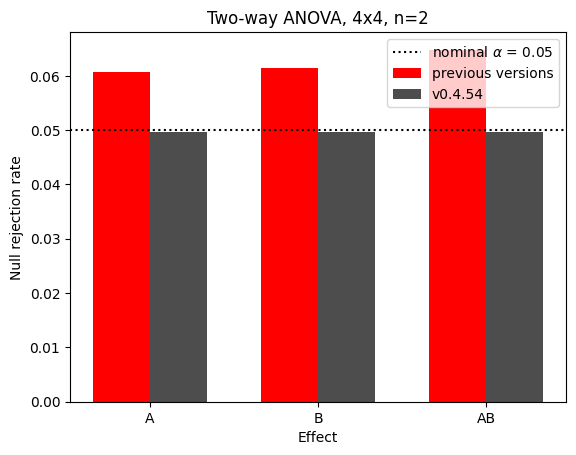

In [8]:
plt.figure()
ax = plt.axes()
x  = np.arange(3)
ax.bar(x-0.17, old, width=0.34, color='r', label='previous versions')
ax.bar(x+0.17, new, width=0.34, color='0.3', label='v0.4.54')
ax.axhline(0.05, color='k', linestyle=':', label=r'nominal $\alpha$ = 0.05')
ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_xlabel('Effect')
ax.set_ylabel('Null rejection rate')
ax.set_title('Two-way ANOVA, 4x4, n=2')
ax.legend()
plt.show()

<br>
<br>

___

## Bug 2: Saturated designs -- example old and new behavior

A saturated design has one observation per cell, so no error can be estimated. Previous versions returned a result anyway:

In [9]:
A1,B1 = balanced((3,4), 1)
y1    = rng.normal(size=A1.size)

with previous_version():
    for label,f in zip(LABELS, spm1d.stats.anova2(y1, A1, B1, equal_var=True).inference(0.05)):
        print( '    %-4s  F = %12.4e  (%g,%3g)   zstar = %.4f' %(label, f.z, f.df[0], f.df[1], f.zstar) )

    A     F =   2.6103e+14  (2, 12)   zstar = 3.8853
    B     F =   3.2453e+15  (3, 12)   zstar = 3.4903
    AB    F =   1.0055e+15  (6, 12)   zstar = 2.9961


Those dfE should be 0 and not 12, so the F-values should be undefined.

In v0.4.54 this is solved by raising an error that alerts users to the problem:

In [10]:
try:
    spm1d.stats.anova2(y1, A1, B1, equal_var=True)
except Exception as e:
    print( '%s:%s' %(type(e).__name__, e) )

SPM1DError:

The "A" effect has no error term:  the "Error" term has zero degrees of freedom.

This happens when the design is saturated -- one observation per cell -- so that nothing is left over with which to estimate error.  Add replicate observations.




The simplest case is a one-way ANOVA with a single observation in each group,
where previous versions declared a significant difference between two single
numbers:

In [11]:
y2,A2 = np.array([1.0, 2.0]), np.array([0,1])

with warnings.catch_warnings():    # the two-level anova1 warning is unrelated to this change
    warnings.simplefilter('ignore')

    with previous_version():
        f = spm1d.stats.anova1(y2, A2, equal_var=True).inference(0.05)
        print( 'previous versions:  F = %.4e (%g,%g)  p = %.4f  h0reject = %s'
               %(f.z, f.df[0], f.df[1], f.p, f.h0reject) )

    try:
        spm1d.stats.anova1(y2, A2, equal_var=True)
    except Exception as e:
        print()
        print( '%s:%s' %(type(e).__name__, e) )

previous versions:  F = 7.8794e+14 (1,2)  p = 0.0000  h0reject = True

SPM1DError:

The "A" effect has no error term:  the "Error" term has zero degrees of freedom.

This happens when the design is saturated -- one observation per cell -- so that nothing is left over with which to estimate error.  Add replicate observations.




The repeated-measures procedures behavior in the old and new versions can be demonstrated as follows:

In [12]:
y3,A3,S3 = np.arange(3, dtype=float), np.array([0,1,2]), np.array([0,0,0])

with previous_version():
    try:
        spm1d.stats.anova1rm(y3, A3, S3, equal_var=True)
    except Exception as e:
        print( 'previous versions:  %s: %s' %(type(e).__name__, e) )

try:
    spm1d.stats.anova1rm(y3, A3, S3, equal_var=True)
except Exception as e:
    print()
    print( '%s:%s' %(type(e).__name__, e) )

previous versions:  IndexError: tuple index out of range

SPM1DError:

The "S" term has no columns, so this design cannot be built.

For the repeated-measures procedures this happens when only one subject is submitted;  at least two are needed.




<br>
<br>

___

## Unaffected cases

Several designs are not affected by these bugs. For example, a 3x4 design with two observations per cell yields identical results in the old and new versions:

In [13]:
A4,B4 = balanced((3,4), 2)
compare_anova2(rng.normal(size=A4.size), A4, B4)

          v0.4.54 and later                   previous versions
    A     F =  2.5473 (2, 12)  p = 0.1197     F =  2.5473 (2, 12)  p = 0.1197
    B     F =  2.1380 (3, 12)  p = 0.1487     F =  2.1380 (3, 12)  p = 0.1487
    AB    F =  3.7156 (6, 12)  p = 0.0253     F =  3.7156 (6, 12)  p = 0.0253


Additionally, **no built-in dataset is affected.** All relevant 0D and 1D datasets were checked on two platforms and
all report the exact error DF.

`spm1d.stats.ttest`, `ttest2`, `ttest_paired`, `regress` and `glm` were never affected: they already computed the error DF correctly as `J - rank(X)`.

<br>
<br>

___

## Summary

**spm1d** versions prior to v0.4.54 are subject to the two bugs described above.

- The error DF was sometimes 1 too high, making *F* too large and *p* too small.
- Saturated designs were mishandled in previous versions, but now yield a consistent error.
- No dataset distributed with **spm1d** is affected.
- Regression and the *t* tests are not affected.

The **spm1d** developers recommend that you re-run your analyses with v0.4.54 or later to check your results;  likely there will be no difference unless your dataset happens to adhere to the problem situations described above.

If you discover any additional problems or bugs, please post them to the [spm1d forum](https://github.com/0todd0000/spm1d/issues).